# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
#Type your code here
import pandas as pd

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
#Type your code here
df = pd.read_csv("../data/dataset.csv")
df.head()

,DataId,who_region,iso3,country_name,city,year,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,type_of_stations,number_of_stations,population,latitude,longitude,who_ms,Air_quality_category
0,0,4_Eur,ESP,Spain,Granada,2010,39.903,Tidak diketahui,40.815,93,Tidak diketahui,99,Somewhere,1,495901,37.185960,-3.608474,1,Safety
1,1,4_Eur,ESP,Spain,Teguise,2010,21.166,6.707,7.536,99,Tidak diketahui,97,Somewhere,1,21101,28.990311,-13.516550,1,Safety
2,2,5_Emr,IRN,Iran (Islamic Republic of),Tehran,2010,93.986,Tidak diketahui,Tidak diketahui,Tidak diketahui,Tidak diketahui,Tidak diketahui,Somewhere,1,9134708,35.711115,51.421332,1,Safety
3,3,4_Eur,TUR,T√ºrkiye,Edirne,2010,64.097,Tidak diketahui,Tidak diketahui,93,Tidak diketahui,Tidak diketahui,Somewhere,1,152628,41.658890,26.585278,1,Safety
4,4,4_Eur,GBR,United Kingdom of Great Britain and Northern I...,Edinburgh,2010,14.213,9.488,27.358,Tidak diketahui,94,99,Somewhere,1,536775,55.962477,-3.314348,1,Safety


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25999 entries, 0 to 25998
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DataId                25999 non-null  int64  
 1   who_region            25999 non-null  object 
 2   iso3                  25999 non-null  object 
 3   country_name          25999 non-null  object 
 4   city                  25999 non-null  object 
 5   year                  25999 non-null  int64  
 6   pm10_concentration    25999 non-null  object 
 7   pm25_concentration    25999 non-null  object 
 8   no2_concentration     25999 non-null  object 
 9   pm10_tempcov          25999 non-null  object 
 10  pm25_tempcov          25999 non-null  object 
 11  no2_tempcov           25999 non-null  object 
 12  type_of_stations      25999 non-null  object 
 13  number_of_stations    25999 non-null  int64  
 14  population            25999 non-null  object 
 15  latitude           

In [7]:
df.describe()

,DataId,year,number_of_stations,latitude,longitude,who_ms
count,25999.000000,25999.000000,25999.000000,25999.000000,25999.000000,25999.000000
mean,13055.089350,2014.474672,1.305127,39.610661,8.174975,0.998846
std,7541.119456,2.346176,1.469442,17.127429,57.981313,0.033950
min,0.000000,2010.000000,1.000000,-53.158316,-159.366240,0.000000
25%,6514.500000,2013.000000,1.000000,36.962300,-2.418600,1.000000
50%,13071.000000,2015.000000,1.000000,43.840800,9.668300,1.000000
75%,19589.500000,2016.000000,1.000000,49.220400,21.538783,1.000000
max,26094.000000,2018.000000,40.000000,69.677498,178.450000,1.000000


In [8]:
df.describe(include="object")

,who_region,iso3,country_name,city,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,type_of_stations,population,Air_quality_category
count,25999,25999,25999,25999,25999,25999,25999,25999,25999,25999,25999,25999,25999
unique,7,109,110,6351,13320,8352,12430,102,102,101,238,5885,2
top,4_Eur,USA,United States of America,Cuenca,Tidak diketahui,Tidak diketahui,Tidak diketahui,Tidak diketahui,Tidak diketahui,Tidak diketahui,Somewhere,Tidak diketahui,Safety
freq,17166,2732,2732,14,6988,12983,8817,11904,16367,11296,12458,10315,25921


In [9]:
cat_cols = []

for col in df.select_dtypes(include=['object', 'string']).columns:
    cat_cols.append(col)

    vc = df[col].value_counts(dropna=True)

    print(col, "===============")
    print("Jumlah unik:", df[col].nunique())

    if len(vc) > 0:
        max_freq = vc.iloc[0]
        modes = vc[vc == max_freq].index.tolist()
        print(f"Modus: {modes} (Frekuensi: {max_freq})")

    print(df[col].unique())
    print()

who_region ===============
Jumlah unik: 7
Modus: ['4_Eur'] (Frekuensi: 17166)
['4_Eur' '5_Emr' '2_Amr' '3_Sear' '1_Afr' '6_Wpr' '7_NonMS']

iso3 ===============
Jumlah unik: 109
Modus: ['USA'] (Frekuensi: 2732)
['ESP' 'IRN' 'TUR' 'GBR' 'DEU' 'FRA' 'GRC' 'MEX' 'AUT' 'USA' 'CZE' 'POL'
 'NLD' 'HUN' 'ITA' 'CHL' 'PER' 'BTN' 'IRL' 'ROU' 'NOR' 'BRA' 'MKD' 'EST'
 'PRT' 'FIN' 'LUX' 'ZAF' 'SAU' 'BEL' 'CHE' 'KOR' 'SVN' 'SWE' 'SVK' 'ECU'
 'BGR' 'IND' 'BGD' 'TUN' 'COL' 'MLT' 'SRB' 'HRV' 'ISL' 'AUS' 'JPN' 'MUS'
 'LTU' 'MNE' 'LIE' 'DNK' 'BIH' 'MNG' 'LVA' 'PHL' 'BHR' 'PAK' 'CYP' 'PRI'
 'SLV' 'SGP' 'NGA' 'MYS' 'PRY' 'ARE' 'LKA' 'IDN' 'CHN' 'GTM' 'VNM' 'MDV'
 'VEN' 'TZA' 'MAR' 'ISR' 'CMR' 'NZL' 'AND' 'JAM' 'QAT' 'MMR' 'GHA' 'LBN'
 'NPL' 'CRI' 'CAN' 'BOL' 'SEN' 'EGY' 'HND' 'PAN' 'MCO' 'KWT' 'GEO' 'ALB'
 'FJI' 'THA' 'URY' 'ARG' 'JOR' 'CUB' 'MDG' 'IRQ' 'RUS' 'ETH' 'TTO' 'UGA'
 'UZB']

country_name ===============
Jumlah unik: 110
Modus: ['United States of America'] (Frekuensi: 2732)
['Spain' 'Iran (Islamic

### Missing Value Analysis

In [10]:
df.isnull().sum()

DataId                  0
who_region              0
iso3                    0
country_name            0
city                    0
year                    0
pm10_concentration      0
pm25_concentration      0
no2_concentration       0
pm10_tempcov            0
pm25_tempcov            0
no2_tempcov             0
type_of_stations        0
number_of_stations      0
population              0
latitude                0
longitude               0
who_ms                  0
Air_quality_category    0
dtype: int64

In [11]:
missing_like = (df == "Tidak diketahui").sum().sort_values(ascending=False)
print(missing_like)

pm25_tempcov            16367
pm25_concentration      12983
pm10_tempcov            11904
no2_tempcov             11296
population              10315
no2_concentration        8817
pm10_concentration       6988
type_of_stations            0
who_ms                      0
longitude                   0
latitude                    0
number_of_stations          0
DataId                      0
who_region                  0
year                        0
city                        0
country_name                0
iso3                        0
Air_quality_category        0
dtype: int64


Kolom pm25, pm10, no2, dan population masih memiliki nilai "Tidak diketahui" sehingga perlu dilakukan penanganan missing value.

### Distribusi Target

In [12]:
df['Air_quality_category'].value_counts()

Air_quality_category
Safety       25921
Dangerous       78
Name: count, dtype: int64

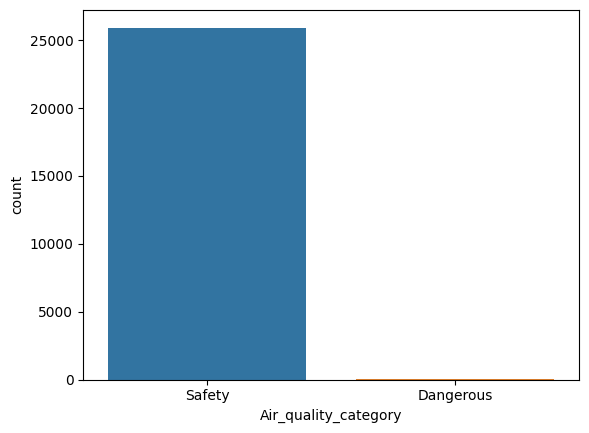

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Air_quality_category')
plt.show()

Dataset bersifat tidak seimbang karena kelas Safety jauh lebih banyak dibanding Dangerous.

### Korelasi Numerik

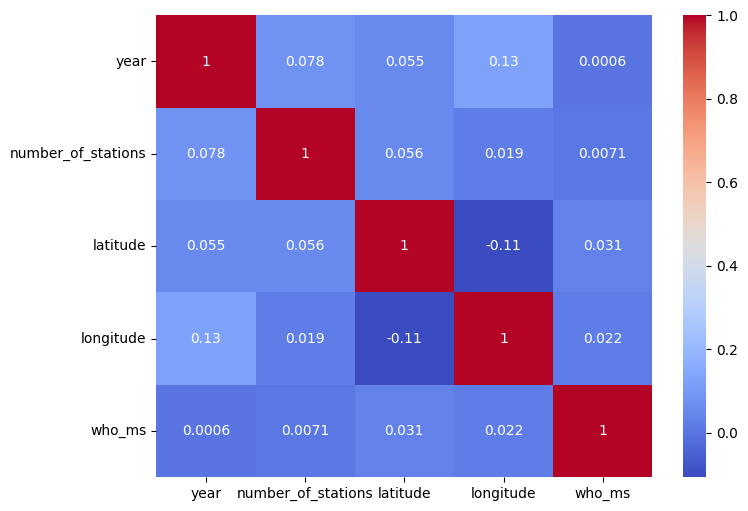

In [14]:
num_cols = [
    'year',
    'number_of_stations',
    'latitude',
    'longitude',
    'who_ms'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Botplot Outlier

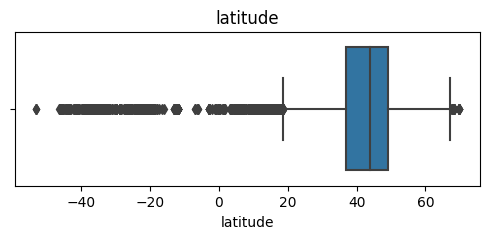

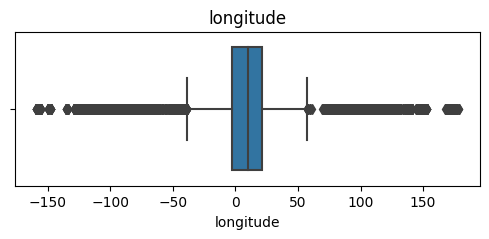

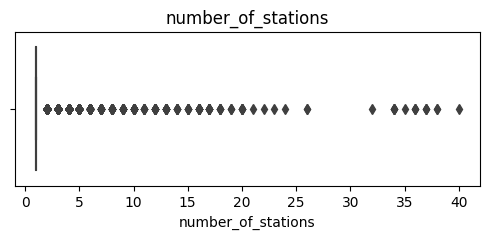

In [15]:
for col in ['latitude','longitude','number_of_stations']:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [16]:
# hapus kolom id
df = df.drop(columns=['DataId'])

In [17]:
# 1. Hapus Duplikat
df = df.drop_duplicates()

In [18]:
# 2. Penanganan Missing Value
# Ganti Tidak Diketahui jadi NaN
import numpy as np
cols = [
    'pm10_concentration',
    'pm25_concentration',
    'no2_concentration',
    'pm10_tempcov',
    'pm25_tempcov',
    'no2_tempcov',
    'population'
]

for col in cols:
    df[col] = df[col].replace('Tidak diketahui', np.nan)

In [19]:
# konversi ke numerik
for col in cols:
    df[col] = pd.to_numeric(df[col])

In [20]:
# imputasi Missing Value
for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [21]:
# encoding target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Air_quality_category'] = le.fit_transform(
    df['Air_quality_category']
)

In [22]:
all_types = set()

for val in df['type_of_stations']:
    for x in str(val).split(','):
        all_types.add(x.strip())

print(sorted(all_types))

['Industrial', 'Residential And Commercial Area', 'Rural', 'Somewhere', 'Suburban', 'Urban', 'Urban Traffic', 'Urban Traffic/Residential And Commercial Area']


In [23]:
station_types = [
    'Urban',
    'Suburban',
    'Rural',
    'Industrial',
    'Residential And Commercial Area',
    'Urban Traffic',
    'Somewhere'
]

for st in station_types:
    df[f"n_{st.lower().replace(' ','_')}"] = (
        df['type_of_stations'].str.count(st)
    )

In [24]:
df = df.drop(columns=['type_of_stations'])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25999 entries, 0 to 25998
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   who_region                         25999 non-null  object 
 1   iso3                               25999 non-null  object 
 2   country_name                       25999 non-null  object 
 3   city                               25999 non-null  object 
 4   year                               25999 non-null  int64  
 5   pm10_concentration                 25999 non-null  float64
 6   pm25_concentration                 25999 non-null  float64
 7   no2_concentration                  25999 non-null  float64
 8   pm10_tempcov                       25999 non-null  float64
 9   pm25_tempcov                       25999 non-null  float64
 10  no2_tempcov                        25999 non-null  float64
 11  number_of_stations                 25999 non-null  int

In [26]:
# encoding kategorical
df = df.drop(columns=['city'])
from sklearn.preprocessing import LabelEncoder

for col in [
    'who_region',
    'iso3',
    'country_name',
]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

In [28]:
df.head()

,who_region,iso3,country_name,year,pm10_concentration,pm25_concentration,no2_concentration,pm10_tempcov,pm25_tempcov,no2_tempcov,...,longitude,who_ms,Air_quality_category,n_urban,n_suburban,n_rural,n_industrial,n_residential_and_commercial_area,n_urban_traffic,n_somewhere
0,3,28,92,-1.907256,39.903,13.2935,40.815,93.0,95.0,99.0,...,-0.203232,0.033989,1,0,0,0,0,0,0,1
1,3,28,92,-1.907256,21.166,6.7070,7.536,99.0,95.0,97.0,...,-0.374120,0.033989,1,0,0,0,0,0,0,1
2,4,45,42,-1.907256,93.986,13.2935,18.162,96.0,95.0,96.0,...,0.745882,0.033989,1,0,0,0,0,0,0,1
3,3,100,99,-1.907256,64.097,13.2935,18.162,93.0,95.0,96.0,...,0.317527,0.033989,1,0,0,0,0,0,0,1
4,3,34,102,-1.907256,14.213,9.4880,27.358,96.0,94.0,99.0,...,-0.198159,0.033989,1,0,0,0,0,0,0,1


In [30]:
df.to_csv("dataset_preprocessed.csv", index=False)